# k平均法クラスタリングによる通信加入者セグメンテーション


## エグゼクティブサマリー

ある通信キャリアは、ポストペイド（後払い）加入者基盤を行動セグメントに分類し、継続利用（リテンション）オファーの対象を絞り込み、データプランを適切なサイズに調整したいと考えている。本ノートブックは合成の加入者利用状況データセットを生成した上で、Base SASによる完全なk平均法セグメンテーション・パイプラインを実行する：**PROC STDIZE**で利用状況の説明変数を標準化し、**PROC FASTCLUS**で候補クラスタ数ごとに疑似F統計量を比較してクラスタ数を選択し、全加入者をスコアリングするFREQ重み付けの最終モデルを当てはめ、学習したセントロイドをエクスポートして翌月のスナップショットを再クラスタリングなしでスコアリングできるようにする。結果として、生の利用状況テレメトリをリテンションのプレイブックに対応付ける再利用可能なセグメンテーションが得られる。


## データソース

**合成データセット：`WORK.SUBSCRIBERS`**（ポストペイド携帯加入者100件、`call streaminit(20260531)`でインライン生成）

| 変数 | 型 | 役割 | 説明 |
|----------|------|------|-------------|
| `cust_id` | 文字 | ID | 加入者識別子（例：`SUB000123`） |
| `tenure_months` | 数値 | 区間入力 | 回線の利用開始からの月数（1～72） |
| `data_gb` | 数値 | 区間入力 | 月平均モバイルデータ利用量（GB） |
| `voice_min` | 数値 | 区間入力 | 月平均音声通話時間（分） |
| `intl_min` | 数値 | 区間入力 | 月平均国際通話時間（分） |
| `support_calls` | 数値 | 区間入力 | 直近90日間のサポート問い合わせ件数 |
| `monthly_charge` | 数値 | 区間入力 | 現在の月額請求額（ドル） |
| `plan_tier` | 文字 | 属性プロファイリング | 料金プラン：`ベーシック`、`プラス`、`アンリミテッド`のいずれか |
| `n_lines` | 数値 | FREQ重み | アカウント上の回線数 |

生成ロジックには3つの潜在的な行動プロファイル——*ライト/バリュー*、*ヘビーデータ/ストリーミング*、*ハイタッチ/離反リスク*——が組み込まれており、クラスタリングで復元すべき実際の構造がある。区間変数がk平均法モデルの入力となり、`plan_tier`は事後プロファイリングのために除外され、`n_lines`は回線数に応じて各アカウントを重み付けする。外部ファイルやネットワークアクセスは使用しない。


## 5つのステップで行う行動セグメンテーション

大手通信キャリアは数百万件のポストペイド回線を抱えており、画一的なリテンション戦略は、いずれにせよ継続してくれる顧客にマージンを浪費する一方、解約寸前の顧客を見逃してしまう。**行動セグメンテーション**は、生の利用状況テレメトリを実用的な顧客タイプへと変換する：価格に敏感な*ライト/バリュー*ユーザー、アップセルの好適ターゲットである*ヘビーデータストリーマー*、そして積極的なケアが必要な*ハイタッチ/離反リスク*アカウントである。

本ノートブックは、SASのk平均法（非階層クラスタ）プロシジャである`PROC FASTCLUS`でセグメンテーションを構築する。手順は以下の通り：

1. 合成だが現実的な加入者利用状況データセットを生成する。
2. **PROC STDIZE**で利用状況の説明変数を共通のスケールに揃える。
3. 候補クラスタ数ごとに疑似F統計量を比較して**クラスタ数を選択する**。
4. 全加入者を**スコアリング**しセグメントをプロファイリングするFREQ重み付けの最終モデルを当てはめる。
5. モデルを翌月のスナップショットに再適用できるよう、**学習したセントロイドをエクスポートする**。


## ステップ1 - 合成の加入者基盤を生成する

100件のポストペイド加入者をシミュレーションする。各加入者は利用シグネチャの異なる3つの潜在プロファイルのいずれかから抽出されるため、復元すべき本物のクラスタ構造が存在する。再現性のために`call streaminit`で乱数ストリームを固定し、`max`/`min`/`round`でシミュレーション値を妥当な範囲に収める。

名義変数`plan_tier`は潜在プロファイルと相関しており（ストリーマーは*アンリミテッド*に、バリュー志向ユーザーは*ベーシック*に偏る）、`n_lines`は後でFREQ重みとして使われ、複数回線のファミリーアカウントが回線数に比例してカウントされるようにする。


In [1]:
データ subscribers;
    呼出 streaminit(20260531);
    長さ cust_id $9 plan_tier $30;
    繰返 i = 1 から 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* 3つの潜在的行動プロファイル、出現率は不均等 */
        u = rand('uniform');
        もし u < 0.45 なら profile = 1;        /* ライト / バリュー          */
        他 もし u < 0.80 なら profile = 2;   /* ヘビーデータストリーマー   */
        他 profile = 3;                    /* ハイタッチ / 離反リスク    */

        もし profile = 1 なら 繰返;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        終了;
        他 もし profile = 2 なら 繰返;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        終了;
        他 繰返;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        終了;

        /* プラン種別は潜在プロファイルと相関する */
        p = rand('uniform');
        もし profile = 1 なら
            plan_tier = ifc(p < 0.70, 'ベーシック', ifc(p < 0.95, 'プラス', 'アンリミテッド'));
        他 もし profile = 2 なら
            plan_tier = ifc(p < 0.65, 'アンリミテッド', ifc(p < 0.90, 'プラス', 'ベーシック'));
        他
            plan_tier = ifc(p < 0.45, 'プラス', ifc(p < 0.80, 'アンリミテッド', 'ベーシック'));

        /* アカウント上の回線数：ほとんどは単一回線 */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* 金額・利用量を現実的な精度に丸める */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        出力;
    終了;
    削除 i u p profile;
実行;

処理 印刷 データ=subscribers(obs=10) noobs 見出;
    見出 cust_id='加入者ID' tenure_months='契約期間(月数)' data_gb='データ利用量(GB)'
          voice_min='音声通話時間(分)' intl_min='国際通話時間(分)' support_calls='サポート問い合わせ件数'
          monthly_charge='月額料金(ドル)' plan_tier='プラン種別' n_lines='回線数';
    表題 '合成加入者利用状況データのサンプル';
実行;


                                                   合成加入者利用状況データのサンプル                                                    

      加入者ID                  プラン種別              契約期間(月数)              データ利用量(GB)                音声通話時間(分)                国際通話時間(分)                        サポート問い合わせ件数              月額料金(ドル)        回線数
SUB000001    ベーシック                                    15                     9.7                      114                        5                                 11                 57.07          2
SUB000002    ベーシック                                    39                     0.6                      214                        2                                  1                 35.88          3
SUB000003    アンリミテッド                                  45                    23.9                      325                        6                                  1                103.94          2
SUB000004    ベーシック                                    41                     1.9  


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## ステップ2 - 説明変数を共通のスケールに揃える

k平均法はユークリッド距離を使うため、生の値のままクラスタリングすると、音声通話時間のような大きな数値の変数がサポート問い合わせ件数のような小さな数値の変数を圧倒してしまう。標準的な対処法は、まずすべての区間変数を平均0・標準偏差1に標準化することである。`METHOD=STD`を指定した**PROC STDIZE**がまさにこれを行い、Zスコア化したコピーを`WORK.SUBS_STD`に書き出す。`cust_id`、`plan_tier`、`n_lines`はそのまま引き継ぎ、後の重み付けとプロファイリングに使えるようにする。


In [2]:
処理 stdize データ=subscribers out=subs_std METHOD=std;
    変数 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
実行;

処理 平均 データ=subs_std mean std maxdec=3;
    変数 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    見出 tenure_months='契約期間(月数)' data_gb='データ利用量(GB)' voice_min='音声通話時間(分)'
          intl_min='国際通話時間(分)' support_calls='サポート問い合わせ件数' monthly_charge='月額料金(ドル)';
    表題 '標準化した説明変数：平均 ~ 0、標準偏差 ~ 1';
実行;


                                                   合成加入者利用状況データのサンプル                                                    

                                               標準化した説明変数：平均 ~ 0、標準偏差 ~ 1                                                

                                                  The MEANS Procedure

 Variable        Label                                       Mean     Std Dev
 ----------------------------------------------------------------------------
 tenure_months   契約期間(月数)                                   0.000       1.000
 data_gb         データ利用量(GB)                                -0.000       1.000
 voice_min       音声通話時間(分)                                 -0.000       1.000
 intl_min        国際通話時間(分)                                  0.000       1.000
 support_calls   サポート問い合わせ件数                               -0.000       1.000
 monthly_charge  月額料金(ドル)                                   0.000       1.000
 ------------------------------------------------------------


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ3 - セグメント数はいくつか？候補kごとに疑似Fを比較する

クラスタ数を勘に頼って決めるのではなく、候補となる各kでFASTCLUSを当てはめ、報告されるモデル適合統計量を読み取る。**疑似F統計量**（クラスタ間分散とクラスタ内分散の比）と**決定係数（R二乗）**はいずれも分離度が高いほど良い値になる。良いkとは、疑似Fが高く、クラスタを追加しても効果が逓減していく手前の値である。短いマクロループで`MAXITER=50`と`CONVERGE=0`（安定するまで反復）を指定してk = 2, 3, 4を実行する。以下の3つのリスティングにある`Pseudo F Statistic`と`Overall R-Squared`の行を比較すると、組み込まれた構造には3つの潜在プロファイルがあり、k = 3が最も強く、最もバランスの取れた解であることがわかる。


In [3]:
%macro pick_k;
    %繰返 k = 2 %から 4;
        処理 FASTCLUS データ=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            変数 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            表題 "候補クラスタ数：k = &k";
        実行;
    %終了;
%mend pick_k;
%pick_k;


                                               標準化した説明変数：平均 ~ 0、標準偏差 ~ 1                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## ステップ4 - 最終セグメンテーションを当てはめ、全加入者をスコアリングする

k = 3を採用し、本番用モデルを当てはめる。この実行は運用セグメンテーションとして完全に定石通りである：

- `FREQ`ステートメントは各アカウントを`n_lines`で重み付けするため、セントロイドを計算する際、4回線のファミリーアカウントは1回線の場合の4倍寄与する。
- `OUT=SCORED`は各加入者について、割り当てられた`CLUSTER`とそのクラスタのセントロイドまでの`DISTANCE`を書き出す。`ID`ステートメントは`cust_id`をそのスコア済みテーブルに引き継ぐ。
- `MEAN=SEG_MEANS`はクラスタごとのセントロイド（標準化スケール）を取得する。
- `OUTSEED=SEG_SEEDS`は最終セントロイドをFASTCLUSが読み戻せるシード形式で保存する——これがステップ6で再適用するエクスポート済みモデルである。

モデル適合統計量はステップ3のスイープですでに確定しているため、ここでは`SHORT`オプションを追加し、リスティングをスコアリング結果を左右するクラスタサイズとセントロイドに絞り込む。


In [4]:
処理 FASTCLUS データ=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    変数 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    度数 n_lines;
    id cust_id;
    見出 cust_id='加入者ID' tenure_months='契約期間(月数)' data_gb='データ利用量(GB)'
          voice_min='音声通話時間(分)' intl_min='国際通話時間(分)' support_calls='サポート問い合わせ件数'
          monthly_charge='月額料金(ドル)' n_lines='回線数';
    表題 '最終セグメンテーション：k = 3、回線数によるFREQ重み付け';
実行;

処理 印刷 データ=seg_means noobs 見出;
    見出 cluster='クラスタ' tenure_months='契約期間(月数)' data_gb='データ利用量(GB)' voice_min='音声通話時間(分)'
          intl_min='国際通話時間(分)' support_calls='サポート問い合わせ件数' monthly_charge='月額料金(ドル)';
    表題 'セグメントのセントロイド（標準化スケール）';
実行;


                                               標準化した説明変数：平均 ~ 0、標準偏差 ~ 1                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## ステップ5 - 実務単位でセグメントをプロファイリングする

スコア済みテーブルには各加入者の`CLUSTER`割り当てが含まれるが、標準化スケールのままではセントロイドは読み取りづらい。クラスタ番号をビジネス上のペルソナに変換するため、割り当て結果を元の`subscribers`テーブルに結合し、ギガバイト・分・ドルという実測単位でプロファイリングする。PROC MEANSはセグメント別に区間変数を要約し、PROC FREQは除外していた`plan_tier`をセグメントとクロス集計して各ペルソナのプラン構成を示す。


                                             セグメントプロファイル：クラスタ別平均利用状況（実測単位）                                              

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months 契約期間(月数)

                                            N
                          クラスタ            Obs      Mean      Std Dev      Minimum      Maximum
                          --------------------------------------------------------------------
                          1                51      33.2         14.7          1.0         61.0
                          2                31      40.5         14.0         17.0         67.0
                          3                18      12.7          7.1          1.0         30.0
                          --------------------------------------------------------------------

                                  Analysis Variable : data_gb データ利用量(GB)

                                        


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


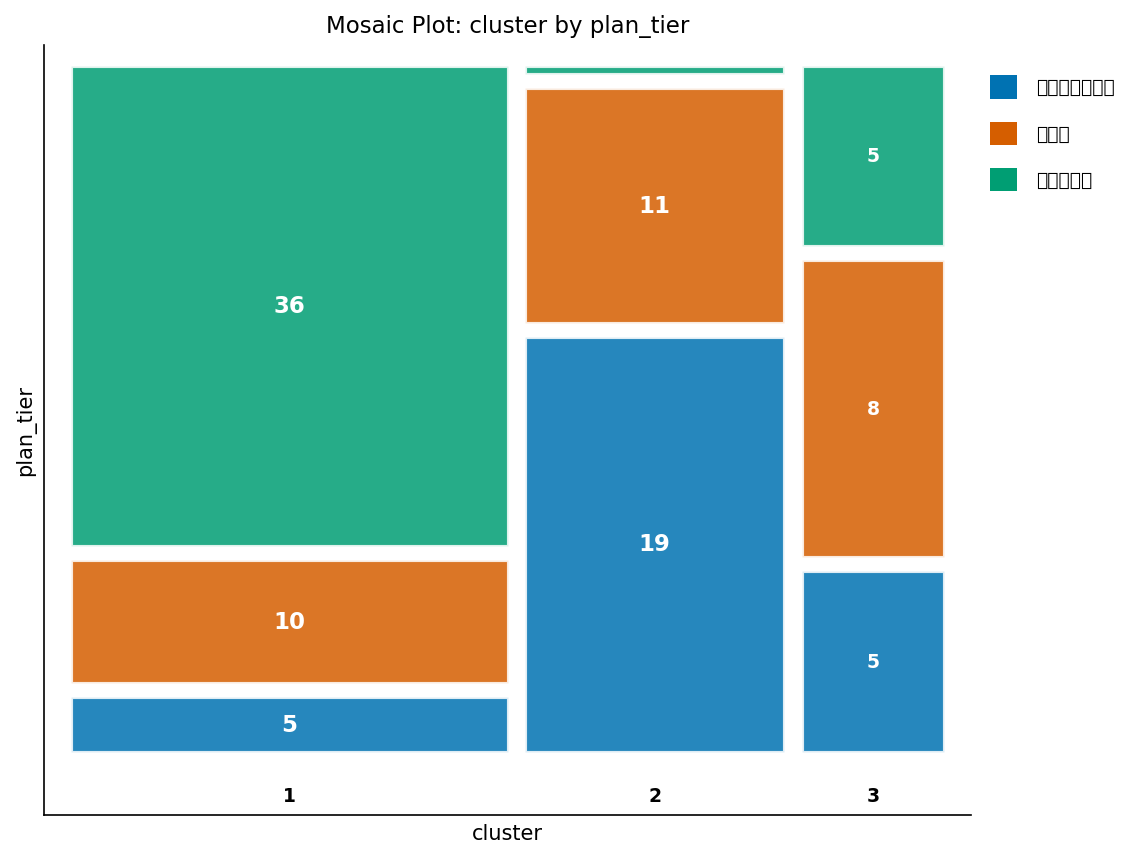

In [5]:
処理 並替 データ=scored out=scored_keys(保持=cust_id cluster);
    基準 cust_id;
実行;

処理 並替 データ=subscribers out=subs_sorted;
    基準 cust_id;
実行;

データ profile;
    結合 subs_sorted(IN=a) scored_keys(IN=b);
    基準 cust_id;
    もし a かつ b;
実行;

処理 平均 データ=profile mean std MIN MAX maxdec=1;
    分類 cluster;
    変数 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    見出 cluster='クラスタ' tenure_months='契約期間(月数)' data_gb='データ利用量(GB)'
          voice_min='音声通話時間(分)' intl_min='国際通話時間(分)' support_calls='サポート問い合わせ件数'
          monthly_charge='月額料金(ドル)';
    表題 'セグメントプロファイル：クラスタ別平均利用状況（実測単位）';
実行;

処理 度数 データ=profile;
    TABLES cluster * plan_tier / nocol nopercent;
    見出 cluster='クラスタ' plan_tier='プラン種別';
    表題 '各セグメント内のプラン種別構成';
実行;


## ステップ6 - モデルを翌月のスナップショットに再適用する

セグメンテーションは、ジョブ全体を再実行せずに再適用できてこそ価値がある。ステップ4で`SEG_SEEDS`に保存したセントロイドは可搬型モデルである。それを`SEED=SEG_SEEDS`と`MAXITER=0`とともに戻すと、FASTCLUSはセントロイドを動かすことなく、各観測値を最も近い保存済みセントロイドに*割り当てる*だけになる——再フィットではなく純粋なスコアリングである。ここでは同じ標準化済みスナップショットを再スコアリングし、エクスポートしたモデルが元の割り当てを再現することを確認する。実運用では、代わりに`DATA=`を翌月の標準化済みスナップショットに向けることになる。


                                                    各セグメント内のプラン種別構成                                                     


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


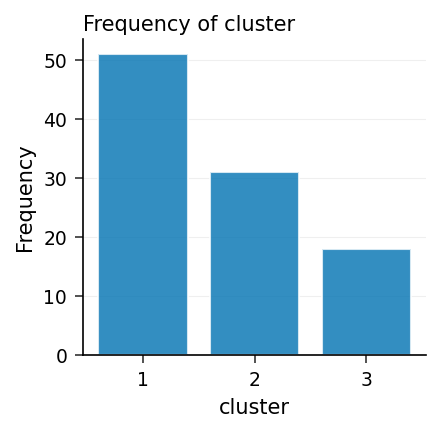

In [6]:
処理 FASTCLUS データ=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    変数 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    表題 'エクスポートしたセントロイドによる新規スナップショットのスコアリング';
実行;

処理 度数 データ=rescored;
    TABLES cluster / nocum;
    見出 cluster='クラスタ';
    表題 'エクスポートモデルで再スコアリングした加入者';
実行;


## 結果の解釈

FASTCLUSはデータに組み込まれた3つの行動セグメントを復元し、プロファイリングテーブルはそれをリテンションのプレイブックへと翻訳する。上記の*セグメントプロファイル*テーブルからセグメント番号を読み取ってほしい——クラスタ番号自体は任意なので、利用シグネチャによって各ペルソナを識別する：

- **ライト/バリューユーザー** - データ利用量が少なく、請求額も控えめ、契約期間は長め、サポート問い合わせはごくわずかで、大半が*ベーシック*。これらの顧客は安定していて価格に敏感であり、正しい対応は値引きではなく*マージンを守る*ことである。適正サイズのプラン提案は、値引きなしに請求額のショックを防ぐ。
- **ヘビーデータストリーマー** - データ利用量が多く、音声・国際通話時間も長く、請求額はプレミアム帯で、大半が*アンリミテッド*。彼らはロイヤルかつ高価値であり、取るべき施策は*アップセルと端末アップグレード*、それに競合のプロモに流れないようにする積極的なネットワーク品質メッセージングである。
- **ハイタッチ/離反リスク** - 契約期間が短く、サポート問い合わせ件数が多く、支払額は中位帯。頻繁なケア対応と短い契約期間は典型的な解約の前兆である。このセグメントには*積極的なリテンションオファー*とサービス回復のフォローアップがふさわしい。

この結果を確かなものにした重要な手続き選択：**PROC STDIZE**は数値の大きい音声通話時間がサポート問い合わせのシグナルを圧倒しないようにした。疑似Fスイープはクラスタ数を勘ではなく根拠に基づいて決定した。`FREQ`重みは複数回線のファミリーアカウントをその規模に比例してカウントした。そして`OUTSEED=`/`SEED=`の往復によりセントロイドをエクスポートしたことで、マーケティングチームは毎月のスナップショットを`MAXITER=0`のFASTCLUS呼び出し一つで再セグメント化でき、再クラスタリングは不要である。
